# Première Tâche

Reproduction du notebook brainbeats_analysis_pca_confmat.ipynb. Voici les sous-tâches sur lesquelles j'aimerais me concentrer.

**Au niveau de la lisibilité:**

- Ajouter des commentaires explicatifs et réorganiser les notebook pour améliorer la lisibilité

**Au niveau des figures:**

- Améliorer la figure de matrice de confusion pour améliorer la lisibilité et l'interprétation (changer les couleurs, mettre les chiffres importants en gras, rendre les axes plus lisibles)
- Ajouter un diagramme à bande pour illustrer le niveau de précision pour chaque genre avec une Baseline


**Sous-tâches supplémentaires :**

- Ajouter un graphique de type T-SNE pour visualiser comment les différents genres se regroupent
- Ajouts de graphiques diagnostiques (À DÉTERMINER)

**Pourquoi cette tâche?**  
L'intérêt principal de cette tâche est de me permettre de développer mes connaissances sur le pipeline de traitement des données d’IRM et d’apprentissage automatique ainsi que d’améliorer mes compétences en visualisation de données. Cette tâche est également très pertinente, car elle me permettra d'apprendre à collaborer avec une collègue à travers Github.



## Section 1 : Chargement des données

Dans cette première section, nous allons télécharger et charger les données IRMf ainsi que les labels correspondants. Nous utiliserons uniquement le sujet sub-005 pour cette expérience.

- Les **données IRMf (.npy)** contiennent l'activité cérébrale mesurée voxel par voxel pendant que les participants écoutaient des extraits musicaux. Cependant, même si on peut distinguer l'activité cérébrale entre chaque extrait, il est impossible de déterminer le genre musical uniquement à partir de ces données.  
- Les **fichiers de labels (.mat)** contiennent le genre musical associé à chaque extrait. On doit extraire ces labels et les associer aux données IRMf pour pouvoir entraîner notre modèle.

Nous vérifions également que les données ont été chargées correctement en inspectant les dimensions des tableaux.

In [3]:
# Commençons par importer les modules nécessaires pour entraîner le modèle SVMimport numpy as np
from scipy.io import loadmat
import os
import urllib.request

from sklearn.decomposition import PCA

from sklearn.model_selection import cross_val_score

from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# Téléchargeons les données! Elles sont disponibles sur Zenodo
Zenodo_Files = {
    'sub-005_Resp_Training.npy': 'https://zenodo.org/records/8275363/files/sub-005_Resp_Training.npy?download=1',
    'sub-005_Resp_Test_Mean.npy': 'https://zenodo.org/records/8275363/files/sub-005_Resp_Test_Mean.npy?download=1',
    'AcrossGenre_Order_Trn.mat':  'https://zenodo.org/records/8275363/files/AcrossGenre_Order_Trn.mat?download=1',
    'AcrossGenre_Order_Test.mat': 'https://zenodo.org/records/8275363/files/AcrossGenre_Order_Test.mat?download=1',
}

def download_data(data_path='./data'):
    """Télécharge les données du sujet 005 depuis Zenodo si elles ne sont pas déjà présentes."""
    os.makedirs(data_path, exist_ok=True)
    for filename, url in Zenodo_Files.items():
        dest = os.path.join(data_path, filename)
        if os.path.exists(dest):
            print(f"Déjà présent, on passe : {filename}")
        else:
            print(f"Téléchargement de {filename} ...")
            urllib.request.urlretrieve(url, dest)
            print(f"  Terminé.")

# --- CONFIGURATION ---
data_path = '../data'
sub = '005'

# --- Téléchargement si nécessaire ---
download_data(data_path)

# Chargeons maintenant les données

# --- Étape 1 : Charger les fichiers IRMf .npy ---
# mmap_mode='r' évite de charger l'ensemble du dataset en RAM
X_train = np.load(f'{data_path}/sub-{sub}_Resp_Training.npy', mmap_mode='r')
X_test  = np.load(f'{data_path}/sub-{sub}_Resp_Test_Mean.npy', mmap_mode='r')

# --- Étape 2 : Transposer pour obtenir la forme (timepoints, voxels) ---
# Chaque ligne = un timepoint, chaque colonne = un voxel
X_train = X_train.T
X_test  = X_test.T

# --- Étape 3 : Charger les fichiers de labels .mat ---
training_labels = loadmat(f'{data_path}/AcrossGenre_Order_Trn.mat')
test_labels     = loadmat(f'{data_path}/AcrossGenre_Order_Test.mat')

# --- Étape 4 : Vérifier les dimensions ---
print("Dimensions X_train :", X_train.shape)
print("Dimensions X_test  :", X_test.shape)
print("Dimensions labels entraînement :", training_labels['across_genre_rn_trn'].shape)

# Extraire la clé valide des labels de test (ignorer les clés de métadonnées)
key = [k for k in test_labels.keys() if not k.startswith('_')][0]
print("Clé labels test :", key)
print("Dimensions labels test :", test_labels[key].shape)

Déjà présent, on passe : sub-005_Resp_Training.npy
Déjà présent, on passe : sub-005_Resp_Test_Mean.npy
Déjà présent, on passe : AcrossGenre_Order_Trn.mat
Déjà présent, on passe : AcrossGenre_Order_Test.mat
Dimensions X_train : (4800, 53421)
Dimensions X_test  : (600, 53421)
Dimensions labels entraînement : (12, 4, 10)
Clé labels test : across_genre_rn_test
Dimensions labels test : (6, 4, 10)


## Partie 2 : Construction des labels (y_train et y_test)

### Objectif
Les données IRMf contiennent uniquement l'activité cérébrale. Pour entraîner un classificateur, on doit associer chaque échantillon à un **label de genre musical**.

### Structure des données
Les tableaux de labels sont structurés comme suit : **runs × répétitions × genres**

Puisque les mêmes extraits sont répétés plusieurs fois, on ne conserve qu'**une seule répétition** pour éviter la redondance.  
On reshape ensuite les labels en un vecteur 1D pour que chaque échantillon corresponde exactement à un label.

In [6]:
# --- LABELS DE TEST ---
# Le tableau de labels de test a la forme (6 runs, 4 répétitions, 10 genres)
# On garde uniquement la première répétition (identique pour toutes les répétitions)
test_label_array = test_labels[key][:, 0, :]  # première répétition, forme (6, 10)

# Aplatir en 1D → forme (60,)
y_test = test_label_array.flatten()
print(y_test.shape)


# --- LABELS D'ENTRAÎNEMENT ---
# Le tableau de labels d'entraînement a la forme (12 runs, 4 répétitions, 10 genres)
# On garde uniquement la première répétition (identique pour toutes les répétitions)
trn_label_array = training_labels['across_genre_rn_trn']

# Aplatir en 1D → forme (480,)
y_train = trn_label_array.reshape(-1)
print(y_train.shape)

(60,)
(480,)


## Partie 3 : Construction du pipeline

Finalement, on peut construire le pipeline pour entraîner et tester notre modèle SVM. Ce pipeline comprend plusieurs étapes.

### 3.1 Moyenne temporelle
Chaque extrait musical est enregistré sur plusieurs points de temps (TRs). Cependant, les modèles d'apprentissage automatique standard s'attendent à recevoir **un seul vecteur de features par échantillon**.

Pour chaque extrait écouté par le participant, l'activité cérébrale a été enregistrée sur plusieurs points de temps (TRs). On fait la moyenne à travers le temps pour obtenir **un seul vecteur de features par extrait**, ce qui est requis par les classificateurs standard.  
Cela signifie qu'au lieu d'avoir l'activité sur les 10 secondes de l'extrait, on n'a que l'activité moyenne.

In [7]:
# --- Étape 1 : Moyenne temporelle ---
# Chaque extrait contient 10 points de temps (TRs)
n_tr = 10
n_voxels = X_train.shape[1]

# Reshape des données en (n_extraits, n_tr, n_voxels)
# Puis moyenne sur la dimension temporelle → (n_extraits, n_voxels)

# Données d'entraînement
X_train_avg = X_train.reshape(480, n_tr, n_voxels).mean(axis=1)
print(X_train_avg.shape)

# Données de test
X_test_avg = X_test.reshape(60, n_tr, n_voxels).mean(axis=1)
print(X_test_avg.shape)

(480, 53421)
(60, 53421)


### 3.2 Création du pipeline

On construit un pipeline avec trois étapes :

1. **Standardisation**  
   Assure que chaque voxel a une moyenne de 0 et une variance de 1. C'est essentiel car la PCA et le SVM sont sensibles à l'échelle des features.

2. **Réduction de dimensions (PCA)**  
   Réduit le nombre de features tout en conservant la majeure partie de la variance.  
   C'est crucial pour les données IRMf, qui sont de haute dimension et bruitées.

3. **Classification (SVM linéaire)**  
   Un Support Vector Machine linéaire est utilisé pour classifier les genres musicaux à partir de l'activité cérébrale.

Utiliser un pipeline garantit que :
- Toutes les étapes de prétraitement sont ajustées uniquement sur les données d'entraînement
- Les mêmes transformations sont appliquées de façon cohérente aux données de test
- Le flux de travail est compatible avec la validation croisée


In [8]:
# --- Étape 2 : Construction du pipeline ---
clf = make_pipeline(
    StandardScaler(),       # centrer et normaliser chaque voxel
    PCA(n_components=50),   # garder les 50 premières composantes principales
    LinearSVC()             # classificateur linéaire
)



In [9]:
# --- Étape 3 : Validation croisée ---

cv_scores = cross_val_score(
    clf,
    X_train_avg,
    y_train,
    cv=5
)

print("Scores CV :", cv_scores)
print("Précision moyenne CV :", cv_scores.mean())

Scores CV : [0.125      0.09375    0.10416667 0.125      0.17708333]
Précision moyenne CV : 0.125


In [10]:
# --- Étape 4 : Entraînement du modèle ---
# Tout le prétraitement (standardisation + PCA) est appris UNIQUEMENT sur les données d'entraînement
clf.fit(X_train_avg, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",50
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'a

In [11]:
# --- Étape 5 : Évaluation du modèle ---
# Les mêmes transformations sont automatiquement appliquées aux données de test
accuracy = clf.score(X_test_avg, y_test)
print("Précision :", accuracy)

Précision : 0.25


## PART 4: VISUALISATION

Après avoir entraîné notre modèle, il est essentiel de visualiser ses performance afin de mieux comprendre son comportement!

Dans cette section, nous utilisons 2 types de visualisations:  

**1. Matrice de confusion :**

La matrice de confusion permet d’évaluer les performances du modèle en comparant :

- les vraies classes (y_test)
- les prédictions du modèle (y_pred)

Chaque ligne correspond à une classe réelle, et chaque colonne à une classe prédite.

- Les éléments sur la diagonale représentent les bonnes prédictions
- Les autres cases correspondent aux erreurs de classification

**Cela permet de voir quelles classes sont bien reconnues et quelles classes sont souvent confondues.**

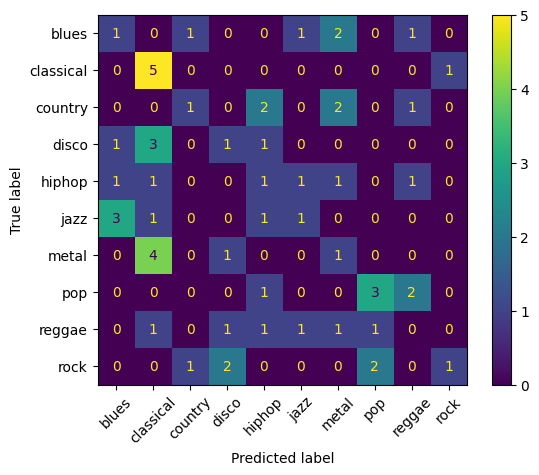

In [12]:
genre_names = [
    "blues",
    "classical",
    "country",
    "disco",
    "hiphop",
    "jazz",
    "metal",
    "pop",
    "reggae",
    "rock"
]

# predictions
y_pred = clf.predict(X_test_avg)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=genre_names
)

disp.plot(xticks_rotation=45)

plt.show()

**1.1 Matrice de confusion avec la diagonale plus visible**

Ici, je modifie légèrement mon code pour mettre en valeur la diagonale (représentant les bonnes prédictions).

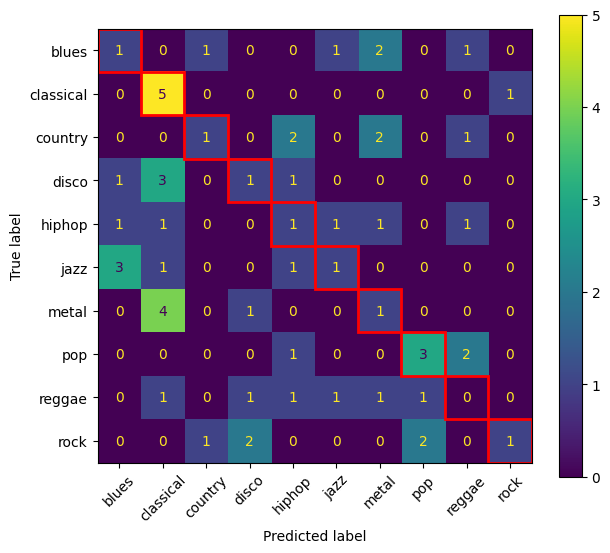

In [13]:
genre_names = ["blues", "classical", "country", "disco", "hiphop","jazz", "metal", "pop", "reggae", "rock"]

# predictions
y_pred = clf.predict(X_test_avg)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

# figure
fig, ax = plt.subplots(figsize=(7, 6))

# display matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=genre_names
)

disp.plot(
    xticks_rotation=45,
    ax=ax,
    colorbar=True
)

# On parcourt chaque classe (chaque case de la diagonale)
for i in range(len(cm)):
    
    # On crée un rectangle autour de la case (i, i)
    rect = plt.Rectangle(
        (i - 0.5, i - 0.5),  # position du coin en bas à gauche du carré
        1, 1,                # largeur et hauteur du carré (taille d'une cellule)
        fill=False,          # ne pas remplir = juste le contour
        edgecolor="red",     # couleur du contour
        linewidth=2)          # épaisseur du contour

    # On ajoute le rectangle au graphique
    ax.add_patch(rect)

plt.show()

**2. Visualisation avec t-SNE**

Le t-SNE (t-distributed Stochastic Neighbor Embedding) est une technique de réduction de dimension. Il permet de projeter des données complexes (ici, les features extraites) dans un espace en 2 dimensions, afin de les visualiser.

**L’objectif est de voir si les différentes classes (genres musicaux) forment des groupes distincts.**

Dans ce graphique :

- chaque point représente une observation
- les couleurs correspondent aux classes
- les groupes compacts indiquent que les données sont bien séparées
- les chevauchements suggèrent des difficultés de classification


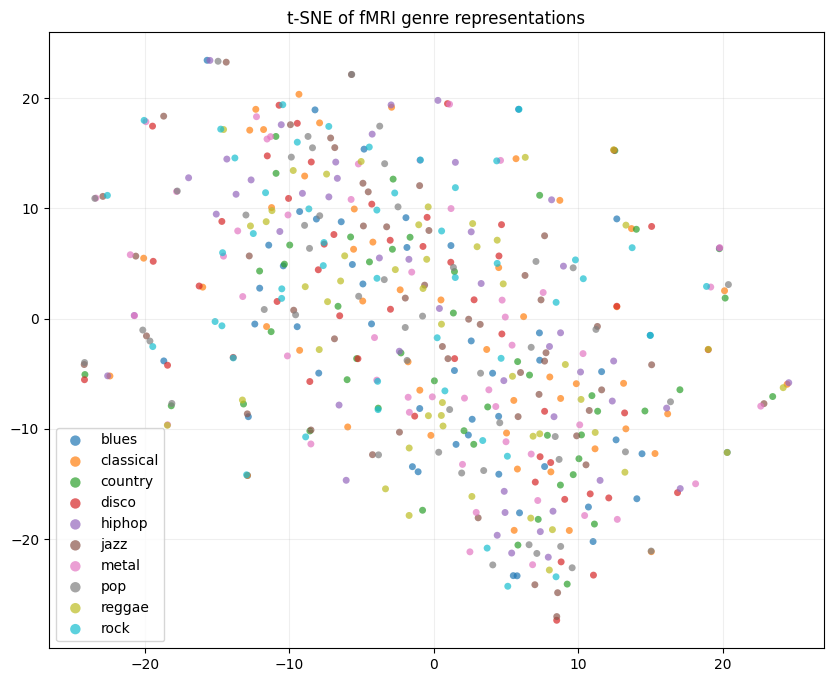

In [14]:
#TSN-E plot

tsne = TSNE(
    n_components=2,     # on projette les données en 2 dimensions (pour visualiser)
    perplexity=30,      # paramètre qui contrôle la notion de voisinage
    random_state=42,    # pour avoir des résultats reproductibles
    init="pca"          # initialisation plus stable avec PCA
)

# On applique t-SNE sur les données d'entraînement
# Résultat : chaque point passe à 2D
X_embedded = tsne.fit_transform(X_train_avg)

# --- Création de la figure ---
plt.figure(figsize=(10, 8))

# --- Plot des points par classe ---
for i, name in enumerate(genre_names):

    # On sélectionne les points appartenant à la classe i
    idx = (y_train == (i + 1))

    # On trace les points de cette classe
    plt.scatter(
        X_embedded[idx, 0],   # coordonnées x (dimension 1)
        X_embedded[idx, 1],   # coordonnées y (dimension 2)
        label=name,           # nom de la classe pour la légende
        s=25,                 # taille des points
        alpha=0.7,            # transparence (utile si les points se chevauchent)
        edgecolors='none'     # pas de contour pour un rendu plus propre
    )

# --- Ajout des éléments visuels ---
plt.legend(markerscale=1.5, fontsize=10)  # légende des classes
plt.title("t-SNE of fMRI genre representations")  # titre
plt.grid(True, alpha=0.2)  # grille légère
plt.show()

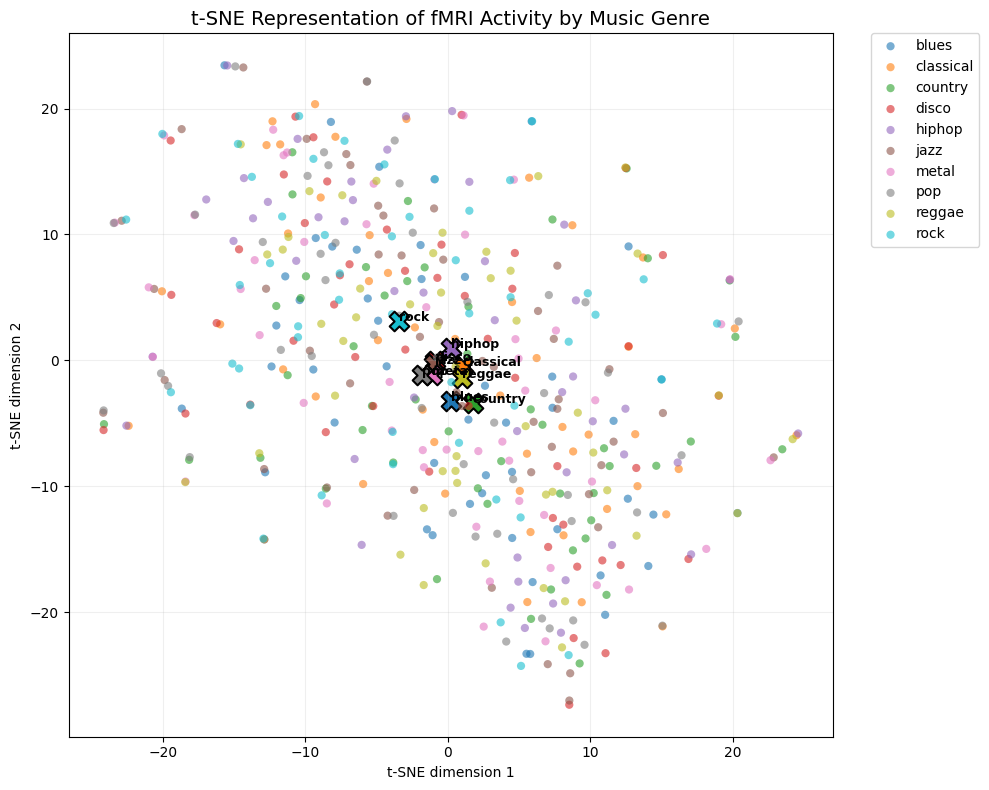

In [15]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# --- t-SNE embedding ---
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    random_state=42
)

X_embedded = tsne.fit_transform(X_train_avg)

# --- figure setup ---
plt.figure(figsize=(10, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(genre_names)))

# --- plot each genre ---
for i, name in enumerate(genre_names):

    # IMPORTANT: adjust depending on your label encoding
    idx = (y_train == (i + 1))

    plt.scatter(
        X_embedded[idx, 0],
        X_embedded[idx, 1],
        s=35,
        alpha=0.6,
        color=colors[i],
        label=name,
        edgecolors="none")

  # --- Calcul du centroïde ---
    # Moyenne des points de la classe → position "typique" du groupe
    centroid = X_embedded[idx].mean(axis=0)

    # --- Affichage du centroïde ---
    plt.scatter(
        centroid[0],
        centroid[1],
        color=colors[i],
        s=200,                # plus gros pour bien le voir
        marker="X",           # forme différente (croix)
        edgecolors="black",   # contour noir pour contraste
        linewidths=1.5)

    # --- Ajout du nom du genre sur le centroïde ---
    plt.text(
        centroid[0],
        centroid[1],
        name,                 # nom du genre
        fontsize=9,
        weight="bold"
    )

# --- Mise en forme ---
plt.title("t-SNE Representation of fMRI Activity by Music Genre", fontsize=14)
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")

plt.grid(alpha=0.2)

# Légende déplacée à droite pour ne pas cacher le graphique
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0
)

# Ajuste automatiquement les marges
plt.tight_layout()

# --- Affichage ---
plt.show()

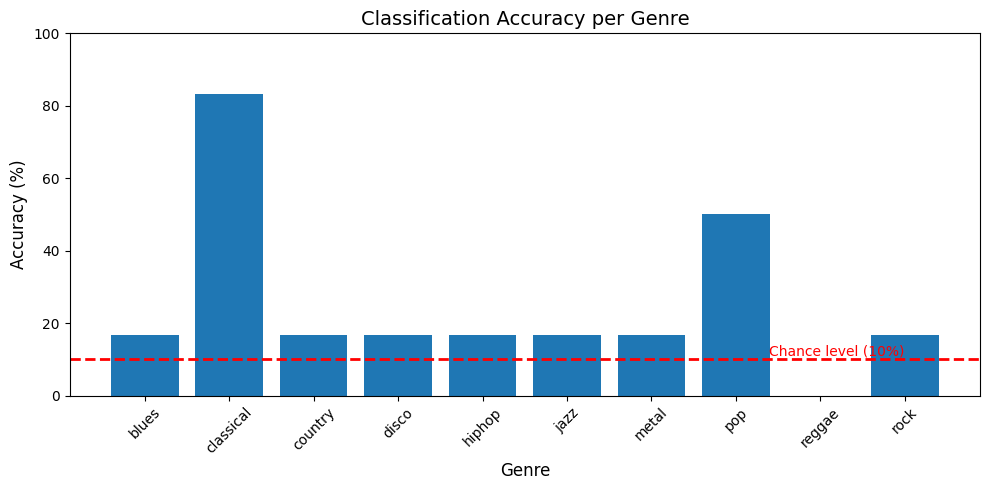

In [17]:
# --- compute accuracy per genre ---

# On récupère les classes uniques présentes dans y_test
genres = np.unique(y_test)

# Liste pour stocker l'accuracy de chaque genre
genre_accuracies = []


# --- Calcul de l'accuracy pour chaque genre ---
for g in genres:
    idx = (y_test == g) # sélection des échantillons appartenant au genre g

    # On compare les prédictions aux vraies valeurs pour ce genre uniquement
    acc = np.mean(y_pred[idx] == y_test[idx]) * 100
    genre_accuracies.append(acc)

# Conversion en array numpy
genre_accuracies = np.array(genre_accuracies)

# --- Création du graphique ---
plt.figure(figsize=(10, 5))

# Création des barres
bars = plt.bar(genre_names, genre_accuracies)

# --- Chance level line ---
chance_level = 10
plt.axhline(y=chance_level, linestyle='--', linewidth=2, color='red')
plt.text(
    len(genre_names) - 1,
    chance_level + 1,
    "Chance level (10%)",
    color='red',
    ha='right',
    fontsize=10)

# Labels
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Classification Accuracy per Genre", fontsize=14)

plt.xticks(rotation=45)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()